In [ ]:
%pylab inline

Populating the interactive namespace from numpy and matplotlib


In [ ]:
!pip install keras-unet

In [ ]:
from keras_unet.models import custom_unet
import tensorflow as tf
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
from PIL import Image
import glob, os

-----------------------------------------
keras-unet init: TF version is >= 2.0.0 - using `tf.keras` instead of `Keras`
-----------------------------------------


In [ ]:
#
# 1. DATA
#

!wget -q https://www.robots.ox.ac.uk/~vgg/data/pets/data/images.tar.gz
!wget -q https://www.robots.ox.ac.uk/~vgg/data/pets/data/annotations.tar.gz
!tar xzf images.tar.gz
!tar xzf annotations.tar.gz

IMG_SIZE = 128
BREED = "Bengal"

image_paths = sorted(glob.glob(f"images/{BREED}_*.jpg"))
print(f"Found {len(image_paths)} images for class '{BREED}'")

X_all = []
y_all = []

for img_path in image_paths:
    fname = os.path.splitext(os.path.basename(img_path))[0]
    mask_path = f"annotations/trimaps/{fname}.png"

    if not os.path.exists(mask_path):
        continue

    img = Image.open(img_path).convert("L").resize((IMG_SIZE, IMG_SIZE))
    img = np.array(img, dtype=np.float32) / 255.0

    mask = Image.open(mask_path).resize((IMG_SIZE, IMG_SIZE), Image.NEAREST)
    mask = np.array(mask, dtype=np.float32)
    mask = np.where(mask == 2, 0.0, 1.0)

    X_all.append(img)
    y_all.append(mask)

X_all = np.array(X_all)[..., None]
y_all = np.array(y_all)[..., None]

# Train/test split
split = int(0.8 * len(X_all))
X_train, X_test = X_all[:split], X_all[split:]
y_train, y_test = y_all[:split], y_all[split:]

print(f"Train: {X_train.shape}, Test: {X_test.shape}")

Found 200 images for class 'Bengal'
Train: (160, 128, 128, 1), Test: (40, 128, 128, 1)


In [ ]:
#
# 2. NETWORK
#


model = custom_unet(
    input_shape=(IMG_SIZE, IMG_SIZE, 1),
    dropout=0.1,
    num_classes=1,
    output_activation='sigmoid'
)


def dice_coef(y_true, y_pred, smooth=1.0):
    y_true_f = tf.keras.backend.flatten(y_true)
    y_pred_f = tf.keras.backend.flatten(y_pred)
    intersection = tf.keras.backend.sum(y_true_f * y_pred_f)
    return (2.0 * intersection + smooth) / (tf.keras.backend.sum(y_true_f) + tf.keras.backend.sum(y_pred_f) + smooth)

model.compile(
    loss='binary_crossentropy',
    metrics=[dice_coef]
)

In [ ]:
#
# 3. CALLBACKS
#

checkpoint = ModelCheckpoint(
    'best_unet.keras',
    monitor='val_loss',
    save_best_only=True,
    verbose=1
)

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True,
    verbose=1
)


In [ ]:
#
# 4. TRAIN
#

history = model.fit(
    X_train, y_train,
    validation_split=0.1,
    epochs=50,
    callbacks=[checkpoint, early_stop]
)

Epoch 1/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - dice_coef: 0.4736 - loss: 0.8799  
Epoch 1: val_loss improved from None to 0.72396, saving model to best_unet.keras

Epoch 1: finished saving model to best_unet.keras
5/5 ━━━━━━━━━━━━━━━━━━━━ 25s 3s/step - dice_coef: 0.4974 - loss: 0.7931 - val_dice_coef: 0.3707 - val_loss: 0.7240
Epoch 2/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - dice_coef: 0.5515 - loss: 0.6276
Epoch 2: val_loss improved from 0.72396 to 0.72024, saving model to best_unet.keras

Epoch 2: finished saving model to best_unet.keras
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step - dice_coef: 0.5598 - loss: 0.6083 - val_dice_coef: 0.3734 - val_loss: 0.7202
Epoch 3/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - dice_coef: 0.5831 - loss: 0.5524
Epoch 3: val_loss did not improve from 0.72024
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - dice_coef: 0.5888 - loss: 0.5447 - val_dice_coef: 0.3789 - val_loss: 0.7353
Epoch 4/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - dice_coef: 0.5798 - loss: 0.5447
Epo

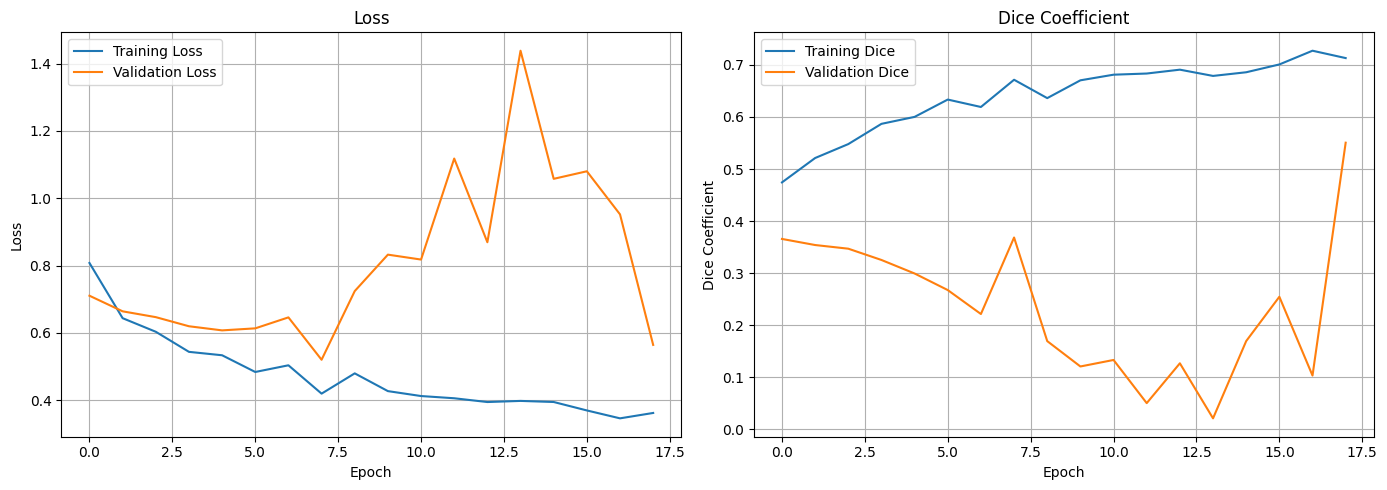

In [ ]:


fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
ax1.plot(history.history['loss'], label='Training Loss')
ax1.plot(history.history['val_loss'], label='Validation Loss')
ax1.set_xlabel('Epoch'); ax1.set_ylabel('Loss'); ax1.set_title('Loss')
ax1.legend(); ax1.grid(True)
ax2.plot(history.history['dice_coef'], label='Training Dice')
ax2.plot(history.history['val_dice_coef'], label='Validation Dice')
ax2.set_xlabel('Epoch'); ax2.set_ylabel('Dice Coefficient'); ax2.set_title('Dice Coefficient')
ax2.legend(); ax2.grid(True)
plt.tight_layout()
plt.show()

2/2 ━━━━━━━━━━━━━━━━━━━━ 6s 2s/step


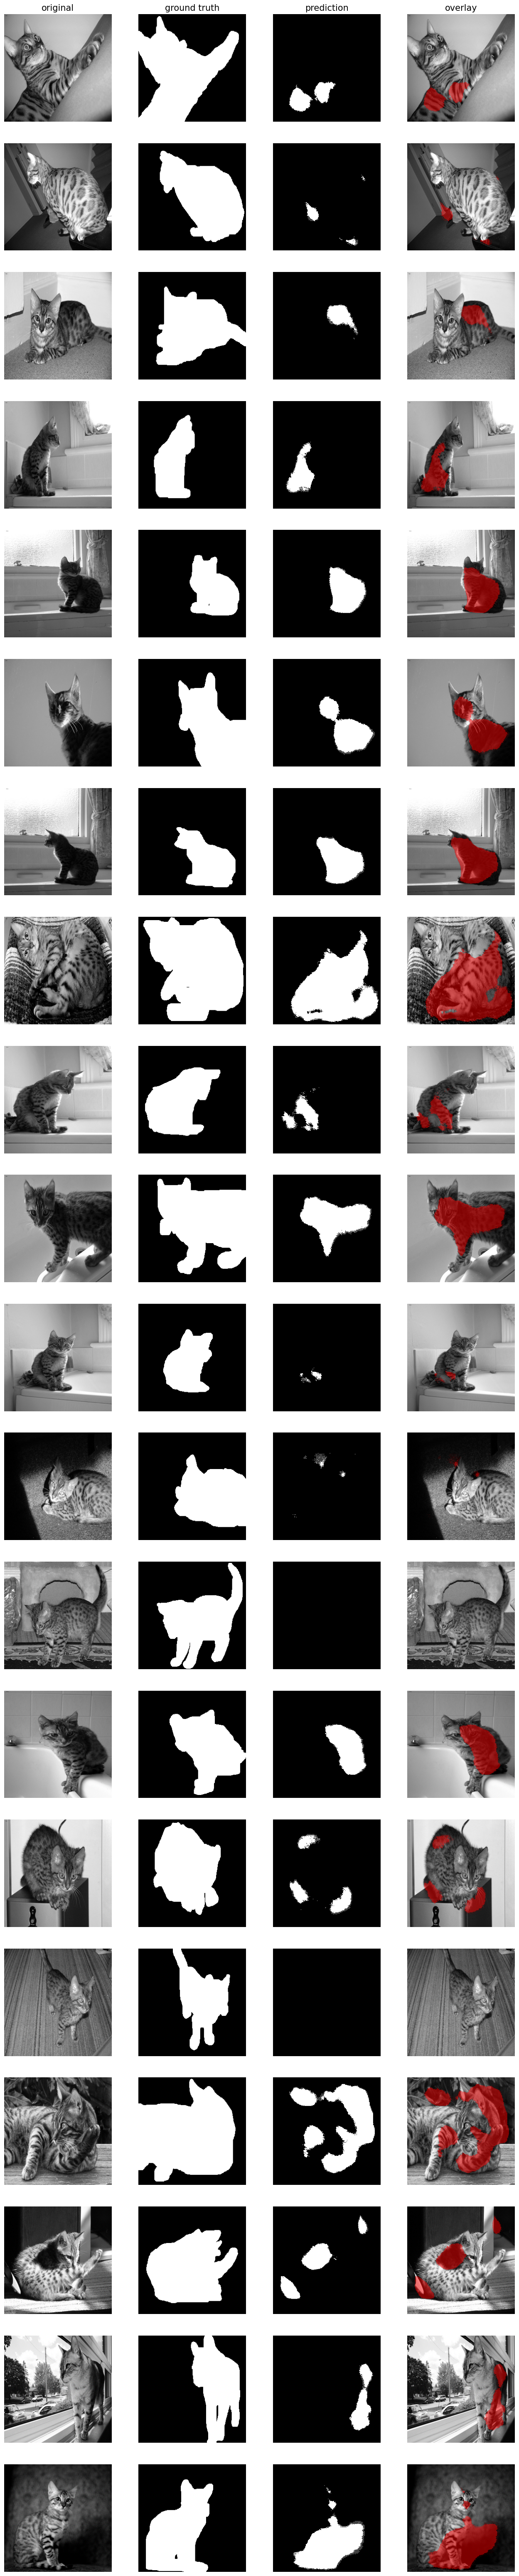

In [ ]:
from keras_unet.utils import plot_imgs

y_pred = model.predict(X_test)
y_pred_binary = (y_pred > 0.5
                 ).astype(np.float32)
plot_imgs(org_imgs=X_test, mask_imgs=y_test, pred_imgs=y_pred_binary, nm_img_to_plot=20)